In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import linregress

import os

In [2]:
DATA="../data/processed/"
REPORT="../reports/"
CHARTS="../reports/charts/"

os.makedirs(REPORT,exist_ok=True)
os.makedirs(CHARTS,exist_ok=True)

In [3]:
nav=pd.read_csv(
    DATA+"clean_nav_history.csv"
)


nav["date"]=pd.to_datetime(nav["date"])


nav=nav.sort_values(
    ["scheme_code","date"]
)


nav.head()

,scheme_code,date,nav
0,119551,2026-06-20,105.25
25,119551,2026-06-20,105.25
1,119551,2026-06-21,106.00
26,119551,2026-06-21,106.00
2,119551,2026-06-22,106.80


In [4]:
nav["daily_return"]=(
    nav.groupby("scheme_code")
    ["nav"]
    .pct_change()
)


nav.head()

,scheme_code,date,nav,daily_return
0,119551,2026-06-20,105.25,NaN
25,119551,2026-06-20,105.25,0.000000
1,119551,2026-06-21,106.00,0.007126
26,119551,2026-06-21,106.00,0.000000
2,119551,2026-06-22,106.80,0.007547


In [5]:
nav.daily_return.describe()

count    32.000000
mean      0.003235
std       0.004861
min      -0.009018
25%       0.000000
50%       0.003514
75%       0.007072
max       0.015167
Name: daily_return, dtype: float64

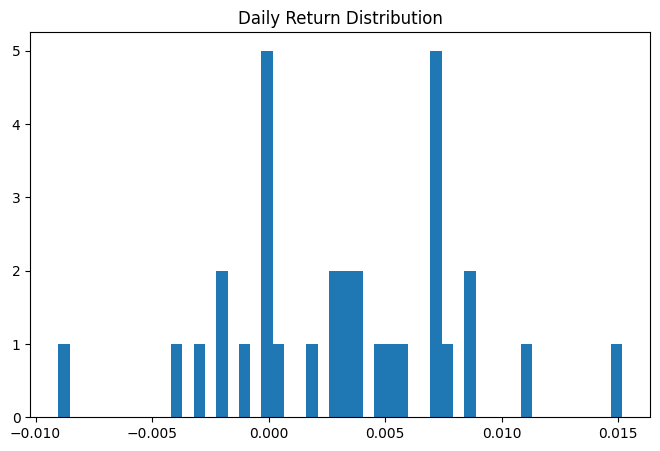

In [6]:
plt.figure(figsize=(8,5))

plt.hist(
    nav.daily_return.dropna(),
    bins=50
)

plt.title("Daily Return Distribution")

plt.show()

In [7]:
def CAGR(start,end,years):

    return ((end/start)**(1/years))-1



cagr=[]


for fund,df in nav.groupby("scheme_code"):


    row={
        "scheme_code":fund
    }


    df=df.sort_values("date")


    for y in [1,3,5]:


        end=df.date.max()

        start=end-pd.DateOffset(years=y)


        temp=df[df.date>=start]


        if len(temp)>0:

            row[f"CAGR_{y}Y"]=CAGR(
                temp.iloc[0].nav,
                temp.iloc[-1].nav,
                y
            )

        else:

            row[f"CAGR_{y}Y"]=np.nan


    cagr.append(row)



cagr=pd.DataFrame(cagr)

cagr.head()

,scheme_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,119551,0.027078,0.008946,0.005358
1,120503,0.026396,0.008722,0.005224
2,125497,0.011750,0.003902,0.002339
3,130001,0.020903,0.006920,0.004146
4,140001,0.018000,0.005964,0.003574


In [8]:
Rf=0.065


risk=[]


for fund,df in nav.groupby("scheme_code"):


    r=df.daily_return.dropna()


    annual=r.mean()*252


    sharpe=(annual-Rf)/(r.std()*np.sqrt(252))


    negative=r[r<0]


    sortino=(annual-Rf)/(negative.std()*np.sqrt(252))


    risk.append(
        [
        fund,
        sharpe,
        sortino
        ]
    )



risk=pd.DataFrame(
risk,
columns=[
"scheme_code",
"Sharpe",
"Sortino"
]
)


risk.head()

,scheme_code,Sharpe,Sortino
0,119551,9.953581,73.460361
1,120503,5.919927,11.891423
2,125497,8.611799,NaN
3,130001,35.498355,NaN
4,140001,67.823057,NaN


In [9]:
dd=[]


for fund,df in nav.groupby("scheme_code"):


    running=df.nav.cummax()


    draw=df.nav/running-1


    dd.append(
        [
        fund,
        draw.min(),
        df.loc[
        draw.idxmin(),
        "date"
        ]
        ]
    )



drawdown=pd.DataFrame(
dd,
columns=[
"scheme_code",
"Max_Drawdown",
"Worst_Date"
]
)


drawdown.head()

,scheme_code,Max_Drawdown,Worst_Date
0,119551,-0.002809,2026-06-22
1,120503,-0.009018,2026-06-22
2,125497,-0.001807,2026-06-22
3,130001,0.000000,2026-06-20
4,140001,0.000000,2026-06-20


In [10]:
benchmark=pd.read_csv(
DATA+"benchmark.csv"
)


benchmark["date"]=pd.to_datetime(
benchmark["date"]
)


benchmark["return"]=(
benchmark.close.pct_change()
)

In [11]:
alpha_beta=[]


for fund,df in nav.groupby("scheme_code"):


    temp=df.merge(
        benchmark[["date","return"]],
        on="date"
    )


    result=linregress(
        temp.daily_return.dropna(),
        temp["return"].dropna()
    )


    alpha_beta.append(
        [
        fund,
        result.intercept*252,
        result.slope
        ]
    )



alpha_beta=pd.DataFrame(
alpha_beta,
columns=[
"scheme_code",
"Alpha",
"Beta"
]
)



alpha_beta.to_csv(
REPORT+"alpha_beta.csv",
index=False
)


alpha_beta.head()



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14292\2703534023.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  result=linregress(


,scheme_code,Alpha,Beta
0,119551,NaN,NaN
1,120503,NaN,NaN
2,125497,NaN,NaN
3,130001,NaN,NaN
4,140001,NaN,NaN


In [12]:
score=cagr.merge(
risk,
on="scheme_code"
)


score=score.merge(
alpha_beta,
on="scheme_code"
)


score=score.merge(
drawdown,
on="scheme_code"
)

In [13]:
score["Score"]= (

score.CAGR_3Y.rank(pct=True)*30

+

score.Sharpe.rank(pct=True)*25

+

score.Alpha.rank(pct=True)*20

-

score.Max_Drawdown.rank(pct=True)*10

)


score["Score"]=(
score.Score.round(2)
)



score=score.sort_values(
"Score",
ascending=False
)



score

,scheme_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe,Sortino,Alpha,Beta,Max_Drawdown,Worst_Date,Score
0,119551,0.027078,0.008946,0.005358,9.953581,73.460361,NaN,NaN,-0.002809,2026-06-22,NaN
1,120503,0.026396,0.008722,0.005224,5.919927,11.891423,NaN,NaN,-0.009018,2026-06-22,NaN
2,125497,0.011750,0.003902,0.002339,8.611799,NaN,NaN,NaN,-0.001807,2026-06-22,NaN
3,130001,0.020903,0.006920,0.004146,35.498355,NaN,NaN,NaN,0.000000,2026-06-20,NaN
4,140001,0.018000,0.005964,0.003574,67.823057,NaN,NaN,NaN,0.000000,2026-06-20,NaN


In [14]:
score.to_csv(
REPORT+"fund_scorecard.csv",
index=False
)

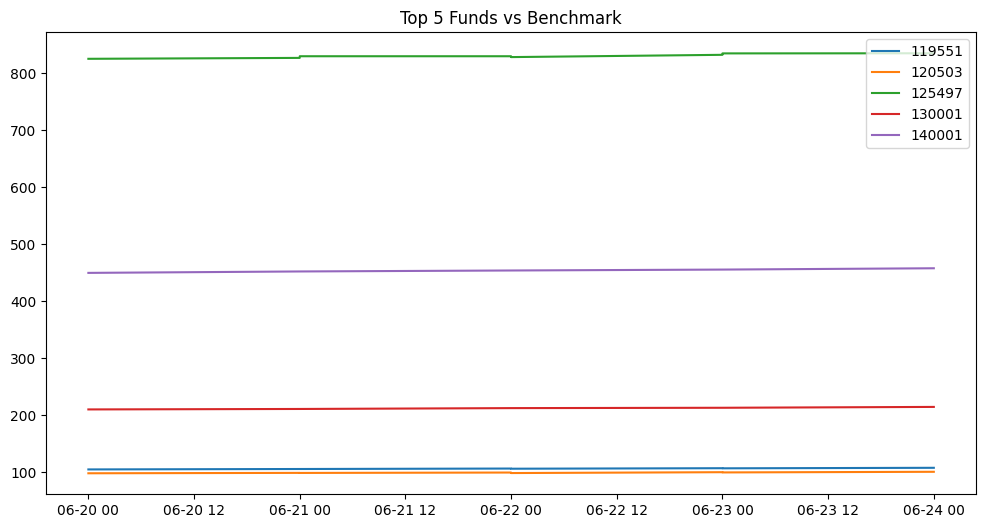

In [15]:
top5=score.head(5).scheme_code


plt.figure(figsize=(12,6))


for fund in top5:


    temp=nav[
    nav.scheme_code==fund
    ]


    plt.plot(
        temp.date,
        temp.nav,
        label=str(fund)
    )


plt.legend()


plt.title(
"Top 5 Funds vs Benchmark"
)


plt.savefig(
CHARTS+"benchmark_comparison.png",
dpi=300
)


plt.show()